# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
294,0.023546,0.050680,-0.030996,-0.005670,-0.016704,0.017788,-0.032356,-0.002592,-0.074093,-0.034215,55.0
274,0.016281,-0.044642,-0.024529,0.035644,-0.007073,-0.003193,-0.013948,-0.002592,0.015568,0.015491,66.0
21,-0.085430,0.050680,-0.022373,0.001215,-0.037344,-0.026366,0.015505,-0.039493,-0.072133,-0.017646,49.0
89,-0.045472,-0.044642,-0.048241,-0.019442,-0.000193,-0.016032,0.067048,-0.039493,-0.024795,0.019633,111.0
408,0.063504,-0.044642,-0.050396,0.107944,0.031454,0.019354,-0.017629,0.023608,0.058038,0.040343,189.0
354,-0.023677,0.050680,0.045529,0.021872,0.109883,0.088873,0.000779,0.034309,0.074191,0.061054,272.0
268,0.063504,0.050680,0.088642,0.070072,0.020446,0.037517,-0.050764,0.071210,0.029297,0.073480,264.0
332,0.030811,-0.044642,0.104809,0.076958,-0.011201,-0.011335,-0.058127,0.034309,0.057108,0.036201,270.0
388,0.052606,0.050680,-0.024529,0.056301,-0.007073,-0.005072,-0.021311,-0.002592,0.026717,-0.038357,110.0
97,-0.027310,-0.044642,0.088642,-0.025191,0.021822,0.042527,-0.032356,0.034309,0.002861,0.077622,279.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isna().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
imputador_media = SimpleImputer(strategy="mean")

data["bmi_media"] = imputador_media.fit_transform(
    data[["bmi"]]
).ravel()

data[["bmi", "bmi_media"]].isna().sum()

bmi          44
bmi_media     0
dtype: int64

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [9]:
imputador_knn = KNNImputer(n_neighbors=2)

datos_knn = imputador_knn.fit_transform(
    data[["bmi", "bp"]]
)

data[["bmi_knn", "bp_knn"]] = datos_knn

data[["bmi_knn", "bp_knn"]].isna().sum()



bmi_knn    0
bp_knn     0
dtype: int64

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

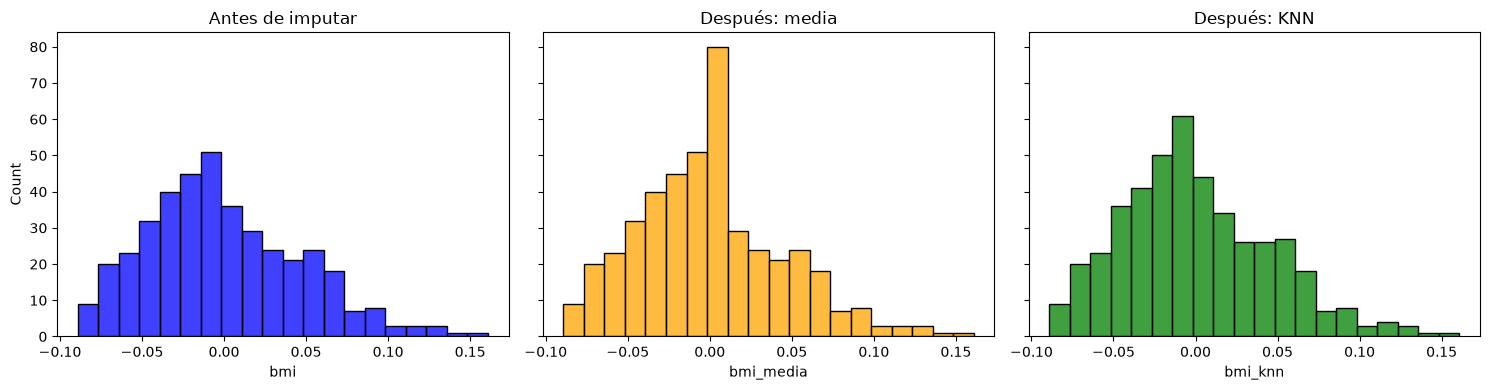

In [10]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4),
    sharex=True,
    sharey=True
)

sns.histplot(
    data["bmi"].dropna(),
    bins=20,
    color="blue",
    ax=axes[0]
)
axes[0].set_title("Antes de imputar")

sns.histplot(
    data["bmi_media"],
    bins=20,
    color="orange",
    ax=axes[1]
)
axes[1].set_title("Después: media")

sns.histplot(
    data["bmi_knn"],
    bins=20,
    color="green",
    ax=axes[2]
)
axes[2].set_title("Después: KNN")

plt.tight_layout()
plt.show()